# NSA.4 – Análisis No Supervisado: Reducción de Dimensionalidad
## Dataset: `Iris.csv`
## Alumno: Santiago González Aguirre
## Fecha: 2026-08-19
---

## 1. Justificación del Algoritmo

Se seleccionó **PCA (Análisis de Componentes Principales)** por las siguientes razones:

- El dataset Iris tiene **4 variables predictoras** (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) que presentan alta correlación entre sí. PCA es la técnica ideal para eliminar redundancia en variables correlacionadas.
- PCA es **lineal**, interpretable y ofrece la **varianza explicada acumulada**, que sirve como criterio objetivo y cuantificable para seleccionar el número de componentes.
- Es el estándar académico para presentar reducción de dimensionalidad en datasets clásicos como Iris.
- Permite visualizar **clusters naturales** en 2D que de otro modo serían invisibles en el espacio 4D original.
- Es **determinístico** (mismo resultado siempre), a diferencia de t-SNE que varía por semilla.

**Alternativas consideradas:** t-SNE (excelente visualización pero no lineal y no conserva varianza), LDA (requiere etiquetas — semi-supervisado), UMAP (más moderno pero más complejo de justificar en contexto académico básico).

## 2. Paso 1 – Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import joblib

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#030712',
    'axes.facecolor': '#0f172a',
    'axes.edgecolor': '#1e293b',
    'axes.labelcolor': '#f1f5f9',
    'xtick.color': '#f1f5f9',
    'ytick.color': '#f1f5f9',
    'text.color': '#f1f5f9',
    'grid.color': '#1e293b',
    'grid.alpha': 0.6,
})

IRIS_COLORS = {
    'Iris-setosa':     '#f472b6',
    'Iris-versicolor': '#34d399',
    'Iris-virginica':  '#60a5fa'
}

print('Librerías cargadas ✓')

Librerías cargadas ✓


## 3. Paso 2 – Carga y exploración del dataset

In [2]:
df = pd.read_csv('Iris.csv')

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'Especies: {df["species"].unique()}')
print(f'Distribución:\n{df["species"].value_counts()}')
df.describe()

Shape: (150, 6)
Columnas: ['Id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Especies: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str
Distribución:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,Id,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 4. Paso 3 – Análisis de correlación previo

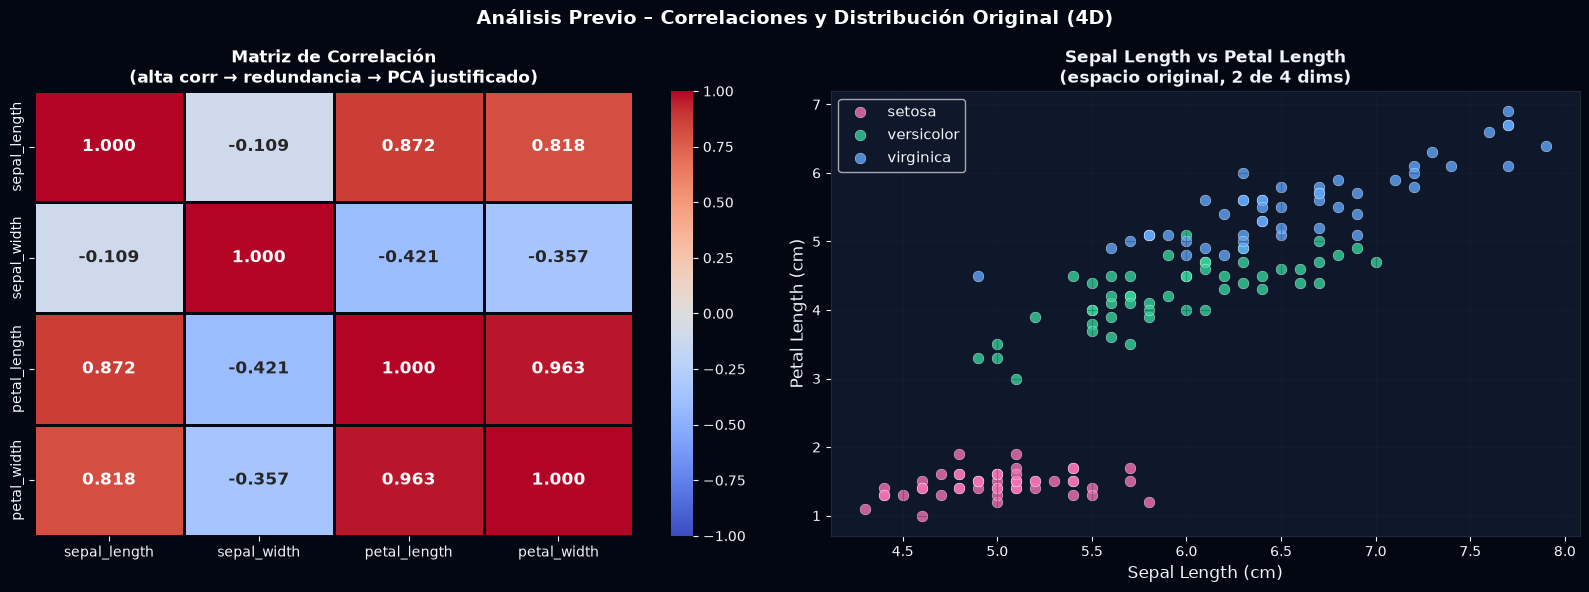

Gráfica guardada como NSA4_correlacion_original.png


In [3]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[feature_cols].copy()
y = df['species']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Previo – Correlaciones y Distribución Original (4D)', fontsize=14, fontweight='bold', color='white')

# Mapa de calor de correlación
ax1 = axes[0]
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax1,
            linewidths=2, linecolor='#030712',
            annot_kws={'size': 12, 'fontweight': 'bold'},
            vmin=-1, vmax=1)
ax1.set_title('Matriz de Correlación\n(alta corr → redundancia → PCA justificado)', 
              fontsize=12, fontweight='bold', color='white')

# Scatter de sepal vs petal (sin reducción)
ax2 = axes[1]
for species, color in IRIS_COLORS.items():
    mask = y == species
    ax2.scatter(X.loc[mask, 'sepal_length'], X.loc[mask, 'petal_length'],
                color=color, alpha=0.8, s=60, edgecolors='white', linewidths=0.3,
                label=species.replace('Iris-', ''))
ax2.set_xlabel('Sepal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Length (cm)', fontsize=12)
ax2.set_title('Sepal Length vs Petal Length\n(espacio original, 2 de 4 dims)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NSA4_correlacion_original.png', dpi=150, bbox_inches='tight', facecolor='#030712')
plt.show()
print('Gráfica guardada como NSA4_correlacion_original.png')

## 5. Paso 4 – Preprocesamiento y PCA completo (todas las componentes)

In [4]:
# Escalar es OBLIGATORIO antes de PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA completo para ver varianza explicada
pca_full = PCA(n_components=4, random_state=42)
pca_full.fit(X_scaled)

varianza_exp    = pca_full.explained_variance_ratio_
varianza_acum   = np.cumsum(varianza_exp)

print('=== VARIANZA EXPLICADA POR COMPONENTE ===')
for i, (ve, va) in enumerate(zip(varianza_exp, varianza_acum), 1):
    print(f'  PC{i}: {ve*100:6.2f}%  acumulada: {va*100:6.2f}%')

print(f'\n→ Con 2 componentes se explica el {varianza_acum[1]*100:.2f}% de la varianza total')
print(f'→ Con 3 componentes se explica el {varianza_acum[2]*100:.2f}% de la varianza total')

=== VARIANZA EXPLICADA POR COMPONENTE ===
  PC1:  72.77%  acumulada:  72.77%
  PC2:  23.03%  acumulada:  95.80%
  PC3:   3.68%  acumulada:  99.48%
  PC4:   0.52%  acumulada: 100.00%

→ Con 2 componentes se explica el 95.80% de la varianza total
→ Con 3 componentes se explica el 99.48% de la varianza total


## 6. Paso 5 – Justificación del número de componentes y Scree Plot

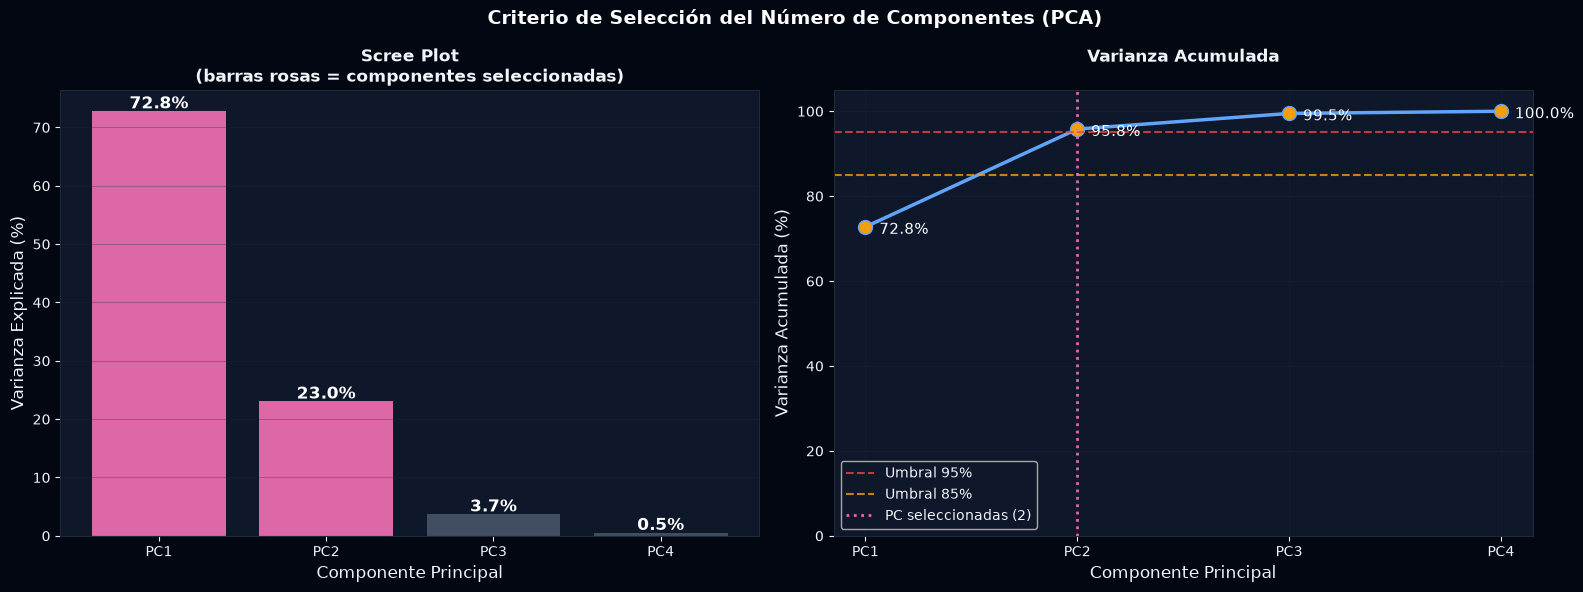

Gráfica guardada como NSA4_scree_varianza.png

=== JUSTIFICACIÓN DE n_components=2 ===
PC1 + PC2 explican 95.80% de la varianza total.
Esto supera el umbral académico del 85% con solo 2 de 4 dimensiones.
La reducción es de 4D → 2D (50% menos dimensiones) con mínima pérdida de información.
Además, 2 componentes permiten visualización directa en un plano 2D interpretable.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Criterio de Selección del Número de Componentes (PCA)', fontsize=14, fontweight='bold', color='white')

# Scree Plot
ax1 = axes[0]
pcs = [f'PC{i}' for i in range(1, 5)]
bar_colors = ['#f472b6' if i < 2 else '#475569' for i in range(4)]
bars = ax1.bar(pcs, varianza_exp * 100, color=bar_colors, alpha=0.9, edgecolor='none')
for bar, val in zip(bars, varianza_exp * 100):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=12)
ax1.set_title('Scree Plot\n(barras rosas = componentes seleccionadas)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Varianza acumulada
ax2 = axes[1]
ax2.plot(pcs, varianza_acum * 100, 'o-', color='#60a5fa', linewidth=2.5, markersize=10, markerfacecolor='#f59e0b')
ax2.axhline(y=95, color='#ef4444', linestyle='--', linewidth=1.5, label='Umbral 95%', alpha=0.8)
ax2.axhline(y=85, color='#f59e0b', linestyle='--', linewidth=1.5, label='Umbral 85%', alpha=0.8)
ax2.axvline(x='PC2', color='#f472b6', linestyle=':', linewidth=2, label='PC seleccionadas (2)', alpha=0.9)
for i, (pc, val) in enumerate(zip(pcs, varianza_acum * 100)):
    ax2.annotate(f'{val:.1f}%', (pc, val), textcoords='offset points', xytext=(10, -5),
                 fontsize=11, color='white')
ax2.set_xlabel('Componente Principal', fontsize=12)
ax2.set_ylabel('Varianza Acumulada (%)', fontsize=12)
ax2.set_title('Varianza Acumulada\n', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('NSA4_scree_varianza.png', dpi=150, bbox_inches='tight', facecolor='#030712')
plt.show()
print('Gráfica guardada como NSA4_scree_varianza.png')

print('\n=== JUSTIFICACIÓN DE n_components=2 ===')
print(f'PC1 + PC2 explican {varianza_acum[1]*100:.2f}% de la varianza total.')
print('Esto supera el umbral académico del 85% con solo 2 de 4 dimensiones.')
print('La reducción es de 4D → 2D (50% menos dimensiones) con mínima pérdida de información.')
print('Además, 2 componentes permiten visualización directa en un plano 2D interpretable.')

## 7. Paso 6 – Aplicación de PCA reducido y visualización

In [6]:
# PCA con 2 componentes
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = y.values

print('Dimensiones originales:', X_scaled.shape)
print('Dimensiones reducidas: ', X_pca.shape)
print(f'\nPC1 varianza: {pca_2d.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2 varianza: {pca_2d.explained_variance_ratio_[1]*100:.2f}%')
df_pca.head()

Dimensiones originales: (150, 4)
Dimensiones reducidas:  (150, 2)

PC1 varianza: 72.77%
PC2 varianza: 23.03%


,PC1,PC2,species
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa


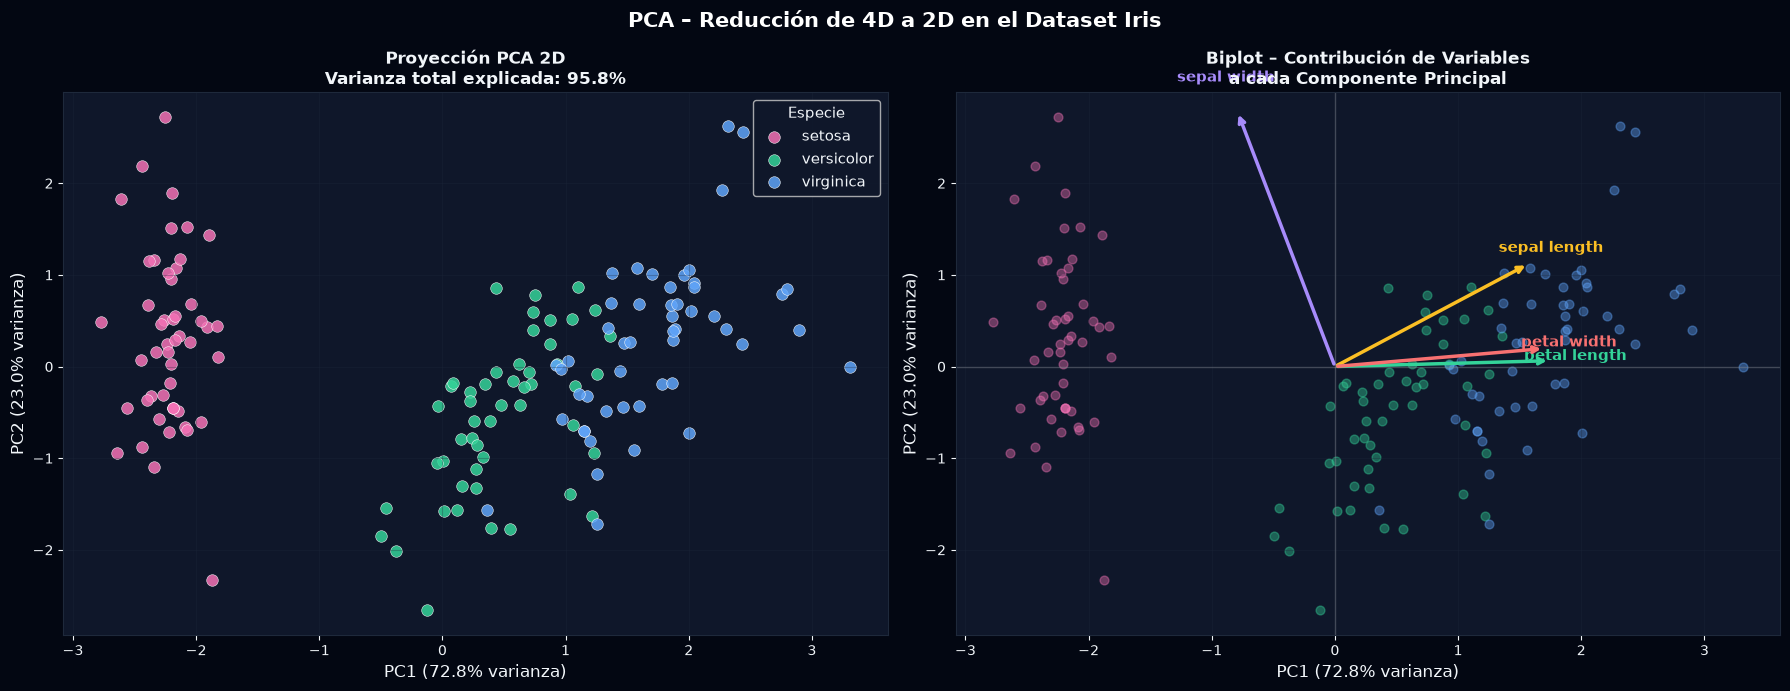

Gráfica guardada como NSA4_pca_2d.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('PCA – Reducción de 4D a 2D en el Dataset Iris', fontsize=15, fontweight='bold', color='white')

# --- Gráfica 1: Proyección PCA 2D ---
ax1 = axes[0]
for species, color in IRIS_COLORS.items():
    mask = df_pca['species'] == species
    ax1.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                color=color, alpha=0.85, s=70, edgecolors='white', linewidths=0.4,
                label=species.replace('Iris-', ''))

ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax1.set_title(f'Proyección PCA 2D\nVarianza total explicada: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=11, title='Especie', title_fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: Biplot (loadings) ---
ax2 = axes[1]
for species, color in IRIS_COLORS.items():
    mask = df_pca['species'] == species
    ax2.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                color=color, alpha=0.4, s=40)

# Vectores de loadings
loadings = pca_2d.components_.T
scale = 3.0
arrow_colors = ['#fbbf24', '#a78bfa', '#34d399', '#f87171']
for i, feature in enumerate(feature_cols):
    ax2.annotate('', 
        xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=arrow_colors[i], lw=2.5)
    )
    ax2.text(loadings[i, 0] * scale * 1.12, loadings[i, 1] * scale * 1.12,
             feature.replace('_', ' '), fontsize=11, fontweight='bold', color=arrow_colors[i], ha='center')

ax2.axhline(y=0, color='white', alpha=0.2, linewidth=1)
ax2.axvline(x=0, color='white', alpha=0.2, linewidth=1)
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax2.set_title('Biplot – Contribución de Variables\na cada Componente Principal', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NSA4_pca_2d.png', dpi=150, bbox_inches='tight', facecolor='#030712')
plt.show()
print('Gráfica guardada como NSA4_pca_2d.png')

## 8. Paso 7 – Tabla de loadings (contribución de variables)

In [8]:
loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
).round(4)

print('=== LOADINGS (contribución de cada variable a cada PC) ===')
print(loadings_df)
print('\nInterpretación:')
print('  PC1: valores altos de carga en petal_length y petal_width → PC1 representa tamaño del pétalo')
print('  PC2: valores altos de carga en sepal_width → PC2 representa ancho del sépalo')

=== LOADINGS (contribución de cada variable a cada PC) ===
                 PC1     PC2
sepal_length  0.5224  0.3723
sepal_width  -0.2634  0.9256
petal_length  0.5813  0.0211
petal_width   0.5656  0.0654

Interpretación:
  PC1: valores altos de carga en petal_length y petal_width → PC1 representa tamaño del pétalo
  PC2: valores altos de carga en sepal_width → PC2 representa ancho del sépalo


## 9. Paso 8 – Guardar el modelo

In [9]:
joblib.dump(pca_2d, 'NSA4_modelo_pca.pkl')
joblib.dump(scaler, 'NSA4_scaler.pkl')
print('✓ Modelo PCA guardado: NSA4_modelo_pca.pkl')
print('✓ Scaler guardado:     NSA4_scaler.pkl')

print('\n=== RESUMEN FINAL ===')
print(f'Algoritmo:              PCA (Análisis de Componentes Principales)')
print(f'Dimensiones originales: 4')
print(f'Dimensiones reducidas:  2  (n_components=2)')
print(f'Varianza PC1:           {pca_2d.explained_variance_ratio_[0]*100:.2f}%')
print(f'Varianza PC2:           {pca_2d.explained_variance_ratio_[1]*100:.2f}%')
print(f'Varianza total retén.:  {sum(pca_2d.explained_variance_ratio_)*100:.2f}%')
print(f'Información perdida:    {(1-sum(pca_2d.explained_variance_ratio_))*100:.2f}%')

✓ Modelo PCA guardado: NSA4_modelo_pca.pkl
✓ Scaler guardado:     NSA4_scaler.pkl

=== RESUMEN FINAL ===
Algoritmo:              PCA (Análisis de Componentes Principales)
Dimensiones originales: 4
Dimensiones reducidas:  2  (n_components=2)
Varianza PC1:           72.77%
Varianza PC2:           23.03%
Varianza total retén.:  95.80%
Información perdida:    4.20%
